# Detección No Supervisada de Anomalías

**Auditoría técnica — CONFAMA**

Los modelos supervisados del notebook anterior son poderosos pero tienen una limitación estructural: solo detectan fraudes que se parecen a fraudes que ya hemos visto. En la práctica, el fraude evoluciona continuamente y aparecen patrones nuevos que no están en el histórico etiquetado.

Isolation Forest aborda esto desde otro ángulo: en lugar de aprender qué es fraude, aprende qué es normal y marca como anómalo lo que se desvía. No usa el target en ningún momento del entrenamiento, lo que lo hace válido para producción real donde las etiquetas no existen.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    'figure.facecolor': '#0F172A', 'axes.facecolor': '#1E293B',
    'axes.edgecolor': '#334155',   'axes.labelcolor': '#94A3B8',
    'xtick.color': '#94A3B8',      'ytick.color': '#94A3B8',
    'text.color': '#F1F5F9',
})
ROJO = '#EF4444'; VERDE = '#22C55E'; AZUL = '#3B82F6'; AMBER = '#F59E0B'
print('✅ Listo')

✅ Listo


In [3]:
# ── Carga del dataset ─────────────────────────────────────────────────────────

df_raw = pd.read_csv('/content/drive/MyDrive/Ejercicio Fraude.csv')

df = df_raw.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hora'] = df['timestamp'].dt.hour
df['dia_semana'] = df['timestamp'].dt.dayofweek
df['mes'] = df['timestamp'].dt.month
df['es_fin_semana'] = (df['dia_semana'] >= 5).astype(int)
df['es_hora_riesgo'] = ((df['hora'] >= 23) | (df['hora'] <= 5)).astype(int)
df['monto_log'] = np.log1p(df['monto'])

# Imputación score_dispositivo
grupo_medianas = df.groupby(['pais_coincide','categoria_comercio'])['score_dispositivo'].median()
for (pais, cat), mediana in grupo_medianas.items():
    if pd.isna(mediana): continue
    mask = (df['pais_coincide']==pais) & (df['categoria_comercio']==cat) & df['score_dispositivo'].isna()
    df.loc[mask, 'score_dispositivo'] = mediana
df['score_dispositivo'] = df['score_dispositivo'].fillna(df['score_dispositivo'].median())

print(f'✅ Dataset: {df.shape} | Fraudes reales: {df["target"].sum()} ({df["target"].mean()*100:.1f}%)')

✅ Dataset: (50000, 15) | Fraudes reales: 750 (1.5%)


## 1. Cálculo del parámetro `contamination`

`contamination` le dice al modelo qué fracción del dataset esperar que sea anómala. El error más común es calcularlo a partir del target (contar fraudes y dividir por total), lo que equivale a usar la respuesta correcta para configurar el examen.

En cambio, lo calculamos a partir de dos reglas de negocio observables y auditables: dispositivos con score en el extremo inferior de la distribución (IQR rule) y transacciones con tres o más intentos fallidos en 24 horas. Ambas señales son verificables en producción sin necesidad de etiquetas. La unión de ambos conjuntos define el tamaño esperado de contaminación.

In [4]:
# Cálculo sin usar target
q1  = df['score_dispositivo'].quantile(0.25)
q3  = df['score_dispositivo'].quantile(0.75)
iqr = q3 - q1
umbral_score = q1 - 1.5 * iqr

mask_outlier_score = df['score_dispositivo'] < umbral_score
mask_intentos      = df['intentos_fallidos_24h'] >= 3
mask_sospechosos   = mask_outlier_score | mask_intentos
n_sospechosos      = mask_sospechosos.sum()

contamination_raw = n_sospechosos / len(df)
contamination     = max(0.005, min(contamination_raw, 0.1))  # clamp razonable

print('=== CÁLCULO DE CONTAMINATION ===')
print(f'Q1 score_dispositivo:          {q1:.2f}')
print(f'Q3 score_dispositivo:          {q3:.2f}')
print(f'IQR:                           {iqr:.2f}')
print(f'Umbral outlier (Q1-1.5*IQR):   {umbral_score:.2f}')
print(f'Registros con score bajo:       {mask_outlier_score.sum():,}')
print(f'Registros con intentos >= 3:    {mask_intentos.sum():,}')
print(f'Total sospechosos (union):      {n_sospechosos:,}')
print(f'contamination = {n_sospechosos}/{len(df)} = {contamination_raw:.4f}')
print(f'contamination (clamped):        {contamination:.4f}')
print(f'\n📌 Esto es independiente de la columna target')

=== CÁLCULO DE CONTAMINATION ===
Q1 score_dispositivo:          79.60
Q3 score_dispositivo:          90.10
IQR:                           10.50
Umbral outlier (Q1-1.5*IQR):   63.85
Registros con score bajo:       759
Registros con intentos >= 3:    922
Total sospechosos (union):      1,344
contamination = 1344/50000 = 0.0269
contamination (clamped):        0.0269

📌 Esto es independiente de la columna target


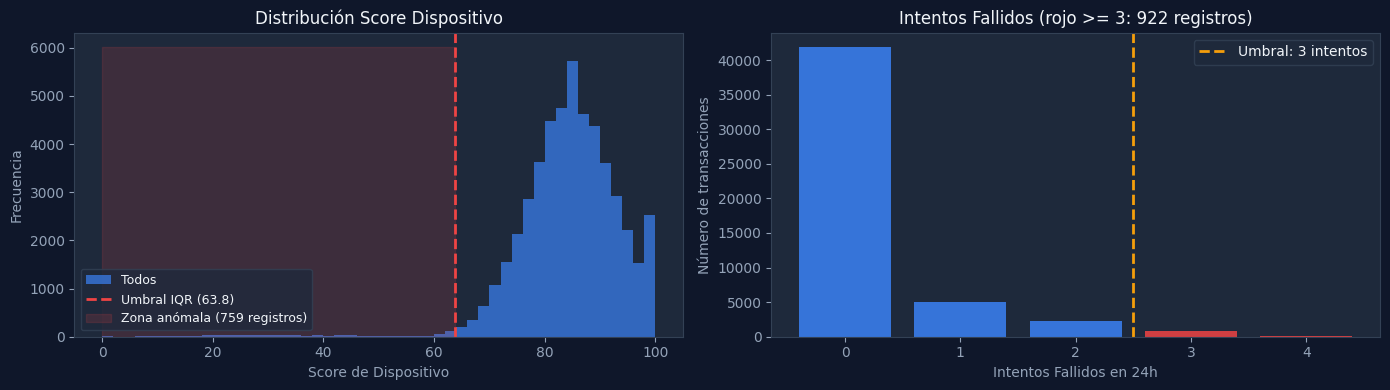

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#0F172A')

# Distribución score_dispositivo con umbral
axes[0].hist(df['score_dispositivo'], bins=50, color=AZUL, alpha=0.7, label='Todos')
axes[0].axvline(umbral_score, color=ROJO, linewidth=2, linestyle='--',
                label=f'Umbral IQR ({umbral_score:.1f})')
axes[0].fill_betweenx([0, axes[0].get_ylim()[1] if len(axes[0].get_ylim())>1 else 5000],
                      df['score_dispositivo'].min(), umbral_score,
                      alpha=0.15, color=ROJO, label=f'Zona anómala ({mask_outlier_score.sum():,} registros)')
axes[0].set_xlabel('Score de Dispositivo')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución Score Dispositivo', color='#F1F5F9', fontsize=12)
axes[0].legend(facecolor='#1E293B', edgecolor='#334155', fontsize=9)

# Distribución intentos fallidos
intentos_vc = df['intentos_fallidos_24h'].value_counts().sort_index()
colors_int = [ROJO if i >= 3 else AZUL for i in intentos_vc.index]
axes[1].bar(intentos_vc.index, intentos_vc.values, color=colors_int, alpha=0.85)
axes[1].axvline(2.5, color=AMBER, linewidth=2, linestyle='--', label='Umbral: 3 intentos')
axes[1].set_xlabel('Intentos Fallidos en 24h')
axes[1].set_ylabel('Número de transacciones')
axes[1].set_title(f'Intentos Fallidos (rojo >= 3: {mask_intentos.sum():,} registros)', color='#F1F5F9', fontsize=12)
axes[1].legend(facecolor='#1E293B', edgecolor='#334155')

plt.tight_layout()
plt.show()

## 2. Entrenamiento del Isolation Forest

Isolation Forest funciona construyendo árboles de partición aleatoria. Los puntos anómalos, al ser infrecuentes y estar en regiones de baja densidad, se aislan con menos cortes que los normales. El score de anomalía es inversamente proporcional a la profundidad promedio de aislamiento.

Usamos 200 estimadores (árboles) para estabilizar los scores; con menos árboles hay varianza en los rankings. `random_state` fijo para reproducibilidad de la auditoría.

In [6]:
FEATURES = [
    'monto_log', 'score_dispositivo', 'intentos_fallidos_24h',
    'hora', 'pais_coincide', 'es_hora_riesgo',
]

X_iso = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iso)

print(f'Features: {FEATURES}')
print(f'contamination = {contamination:.4f} ({int(contamination*len(df)):,} anomalías esperadas)')
print('Entrenando Isolation Forest...')

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_scaled)

scores = iso.decision_function(X_scaled)   # mayor = más normal
preds  = iso.predict(X_scaled)              # -1 = anomalía

df['anomaly_score'] = scores
df['es_anomalia']   = (preds == -1).astype(int)

n_anomalias = df['es_anomalia'].sum()
print(f'\n✅ Isolation Forest entrenado')
print(f'Anomalías detectadas: {n_anomalias:,} ({n_anomalias/len(df)*100:.2f}% del total)')

Features: ['monto_log', 'score_dispositivo', 'intentos_fallidos_24h', 'hora', 'pais_coincide', 'es_hora_riesgo']
contamination = 0.0269 (1,344 anomalías esperadas)
Entrenando Isolation Forest...

✅ Isolation Forest entrenado
Anomalías detectadas: 1,344 (2.69% del total)


## 3. Distribución de scores de anomalía

Antes de usar los scores para tomar decisiones conviene entender su distribución. En un dataset con contaminación moderada esperamos ver una distribución asimétrica con una cola hacia valores negativos (más anómalos). Si la distribución fuera bimodal clara, el modelo estaría separando bien dos poblaciones.

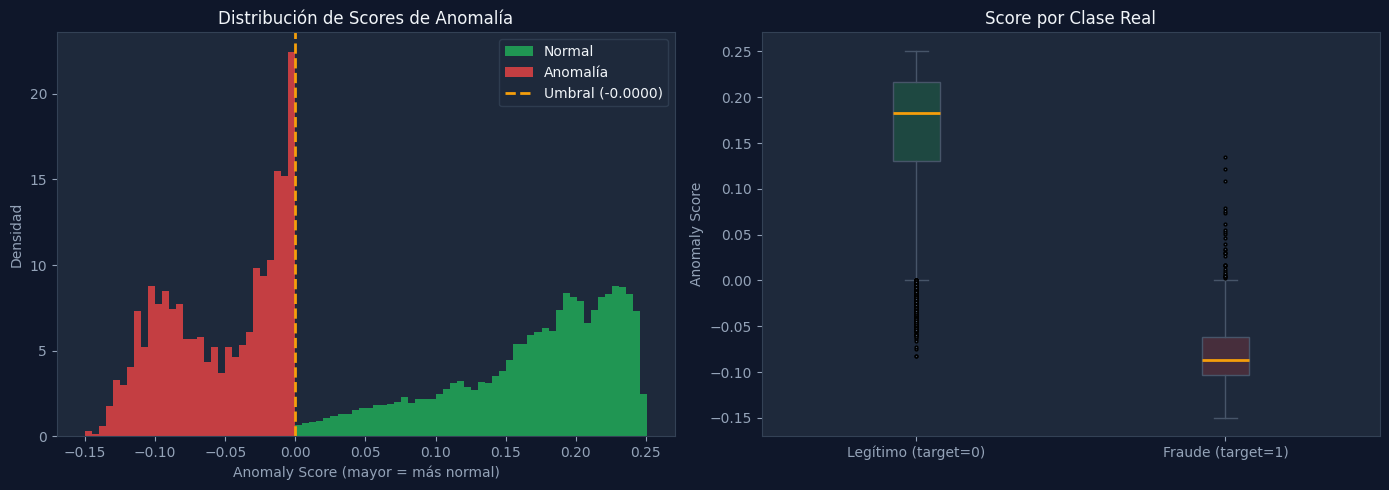

Mediana score legítimo: 0.1832
Mediana score fraude:   -0.0870
💡 El modelo asigna scores más bajos a los fraudes sin haber visto el target


In [7]:
threshold_score = float(np.percentile(scores[preds == -1], 100))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0F172A')

# Histograma de scores
normal_scores = scores[preds == 1]
anom_scores   = scores[preds == -1]
axes[0].hist(normal_scores, bins=50, color=VERDE, alpha=0.7, label='Normal', density=True)
axes[0].hist(anom_scores,   bins=30, color=ROJO,  alpha=0.8, label='Anomalía', density=True)
axes[0].axvline(threshold_score, color=AMBER, linewidth=2, linestyle='--',
                label=f'Umbral ({threshold_score:.4f})')
axes[0].set_xlabel('Anomaly Score (mayor = más normal)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de Scores de Anomalía', color='#F1F5F9', fontsize=12)
axes[0].legend(facecolor='#1E293B', edgecolor='#334155')

# Score vs target real (validación interna)
scores_legit  = scores[df['target'] == 0]
scores_fraude = scores[df['target'] == 1]
bp = axes[1].boxplot(
    [scores_legit, scores_fraude],
    labels=['Legítimo (target=0)', 'Fraude (target=1)'],
    patch_artist=True,
    boxprops=dict(facecolor='#1E293B', color='#475569'),
    medianprops=dict(color=AMBER, linewidth=2),
    whiskerprops=dict(color='#475569'),
    capprops=dict(color='#475569'),
    flierprops=dict(markerfacecolor='#475569', markersize=2),
)
bp['boxes'][0].set_facecolor(VERDE + '33')
bp['boxes'][1].set_facecolor(ROJO  + '33')
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Score por Clase Real', color='#F1F5F9', fontsize=12)

plt.tight_layout()
plt.show()

print(f'Mediana score legítimo: {np.median(scores_legit):.4f}')
print(f'Mediana score fraude:   {np.median(scores_fraude):.4f}')
print('💡 El modelo asigna scores más bajos a los fraudes sin haber visto el target')

## 4. Validación contra el target

Esta sección solo es posible porque estamos en un entorno de reto/auditoría donde tenemos acceso a las etiquetas. En producción real este paso no existiría.

Lo que medimos aquí es cuántos de los registros que el modelo marcó como anómalos coinciden con fraudes etiquetados. No es una métrica de entrenamiento (el modelo nunca vio el target), sino una validación post-hoc de que la definición de anomalía que usamos captura comportamiento fraudulento real.

In [8]:
tp_anom = int(((df['es_anomalia'] == 1) & (df['target'] == 1)).sum())
fp_anom = int(((df['es_anomalia'] == 1) & (df['target'] == 0)).sum())
fn_anom = int(((df['es_anomalia'] == 0) & (df['target'] == 1)).sum())
tn_anom = int(((df['es_anomalia'] == 0) & (df['target'] == 0)).sum())

prec = tp_anom / (tp_anom + fp_anom) if (tp_anom + fp_anom) > 0 else 0
rec  = tp_anom / (tp_anom + fn_anom) if (tp_anom + fn_anom) > 0 else 0
f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0

print('=== VALIDACIÓN INTERNA (solo para el reto) ===')
print(f'TP  (fraudes detectados correctamente): {tp_anom}')
print(f'FP  (legítimos marcados como anomalía): {fp_anom}')
print(f'FN  (fraudes no detectados):            {fn_anom}')
print(f'TN  (legítimos sin marcar):             {tn_anom}')
print(f'\nPrecision: {prec:.3f}')
print(f'Recall:    {rec:.3f}')
print(f'F1:        {f1:.3f}')

fraudes_capturados_pct = tp_anom / df['target'].sum() * 100
print(f'\n📊 {fraudes_capturados_pct:.1f}% de los fraudes conocidos están dentro de las anomalías detectadas')
print(f'📌 El modelo detecta patrones de riesgo sin usar las etiquetas')

=== VALIDACIÓN INTERNA (solo para el reto) ===
TP  (fraudes detectados correctamente): 718
FP  (legítimos marcados como anomalía): 626
FN  (fraudes no detectados):            32
TN  (legítimos sin marcar):             48624

Precision: 0.534
Recall:    0.957
F1:        0.686

📊 95.7% de los fraudes conocidos están dentro de las anomalías detectadas
📌 El modelo detecta patrones de riesgo sin usar las etiquetas


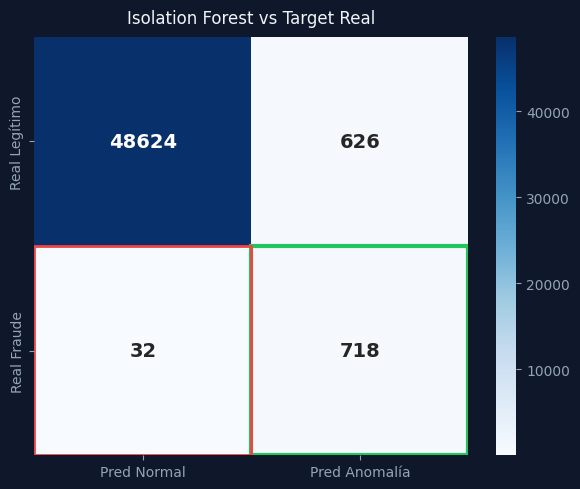

In [9]:
cm_arr = np.array([[tn_anom, fp_anom], [fn_anom, tp_anom]])

fig, ax = plt.subplots(figsize=(6, 5), facecolor='#0F172A')
sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Normal','Pred Anomalía'],
            yticklabels=['Real Legítimo','Real Fraude'],
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Isolation Forest vs Target Real', color='#F1F5F9', fontsize=12, pad=10)
ax.add_patch(plt.Rectangle((1,1), 1, 1, fill=False, edgecolor=VERDE, lw=3))
ax.add_patch(plt.Rectangle((0,1), 1, 1, fill=False, edgecolor=ROJO,  lw=2))
plt.tight_layout()
plt.show()

## 5. Top 20 anomalías más severas

Inspeccionamos las transacciones con score más extremo para dos propósitos: verificar que tienen características coherentes con fraude (no son errores de datos) y construir intuición sobre qué patrones el modelo está capturando.

In [10]:
top_anomalias = (
    df[df['es_anomalia'] == 1]
    .nsmallest(20, 'anomaly_score')
    [[
        'id_transaccion', 'anomaly_score', 'monto', 'categoria_comercio',
        'hora', 'pais_coincide', 'score_dispositivo', 'intentos_fallidos_24h', 'target'
    ]]
    .reset_index(drop=True)
)

# Formatear para display
top_display = top_anomalias.copy()
top_display['anomaly_score'] = top_display['anomaly_score'].round(4)
top_display['monto'] = top_display['monto'].round(2)
top_display['score_dispositivo'] = top_display['score_dispositivo'].round(1)
top_display['target'] = top_display['target'].map({1:'🔴 FRAUDE', 0:'🟢 LEGÍTIMO'})

print('TOP 20 TRANSACCIONES MÁS ANÓMALAS (score más negativo = más anómala)')
display(top_display)

TOP 20 TRANSACCIONES MÁS ANÓMALAS (score más negativo = más anómala)


,id_transaccion,anomaly_score,monto,categoria_comercio,hora,pais_coincide,score_dispositivo,intentos_fallidos_24h,target
0,TX_040010,-0.1500,879.47,Retail,23,0,12.3,4,🔴 FRAUDE
1,TX_038590,-0.1455,1080.57,Viajes,23,0,27.4,4,🔴 FRAUDE
2,TX_034422,-0.1437,925.36,Electrónica,23,0,36.0,4,🔴 FRAUDE
3,TX_005965,-0.1382,531.74,Viajes,23,0,14.5,3,🔴 FRAUDE
4,TX_044971,-0.1379,843.73,Viajes,23,0,23.9,3,🔴 FRAUDE
5,TX_014778,-0.1364,780.74,Electrónica,23,0,28.6,3,🔴 FRAUDE
6,TX_017618,-0.1351,977.47,Electrónica,1,0,19.2,4,🔴 FRAUDE
7,TX_029390,-0.1333,813.41,Viajes,2,0,3.0,4,🔴 FRAUDE
8,TX_009307,-0.1314,755.39,Electrónica,23,0,48.3,3,🔴 FRAUDE
9,TX_018005,-0.1312,682.86,Retail,23,0,13.1,2,🔴 FRAUDE


## 6. Patrones en las anomalías detectadas

Agregamos las anomalías detectadas por variables categóricas y temporales para identificar si hay concentraciones específicas. Esto es relevante operativamente: si el 80% de las anomalías caen en un rango horario o categoría de comercio particular, se pueden diseñar reglas de alerta más eficientes.

In [11]:
anomalias_df = df[df['es_anomalia'] == 1]
normales_df  = df[df['es_anomalia'] == 0]

print('=== PERFIL DE LAS ANOMALÍAS vs TRANSACCIONES NORMALES ===')
cols_analisis = ['monto', 'score_dispositivo', 'intentos_fallidos_24h', 'hora', 'pais_coincide', 'es_hora_riesgo']
comparativa = pd.DataFrame({
    'Anomalías': anomalias_df[cols_analisis].mean(),
    'Normales':  normales_df[cols_analisis].mean(),
}).round(3)
comparativa['Ratio'] = (comparativa['Anomalías'] / comparativa['Normales']).round(2)
print(comparativa)

=== PERFIL DE LAS ANOMALÍAS vs TRANSACCIONES NORMALES ===
                       Anomalías  Normales  Ratio
monto                    263.461    75.404   3.49
score_dispositivo         61.805    84.885   0.73
intentos_fallidos_24h      2.086     0.197  10.59
hora                       8.461    11.545   0.73
pais_coincide              0.208     0.940   0.22
es_hora_riesgo             0.806     0.287   2.81


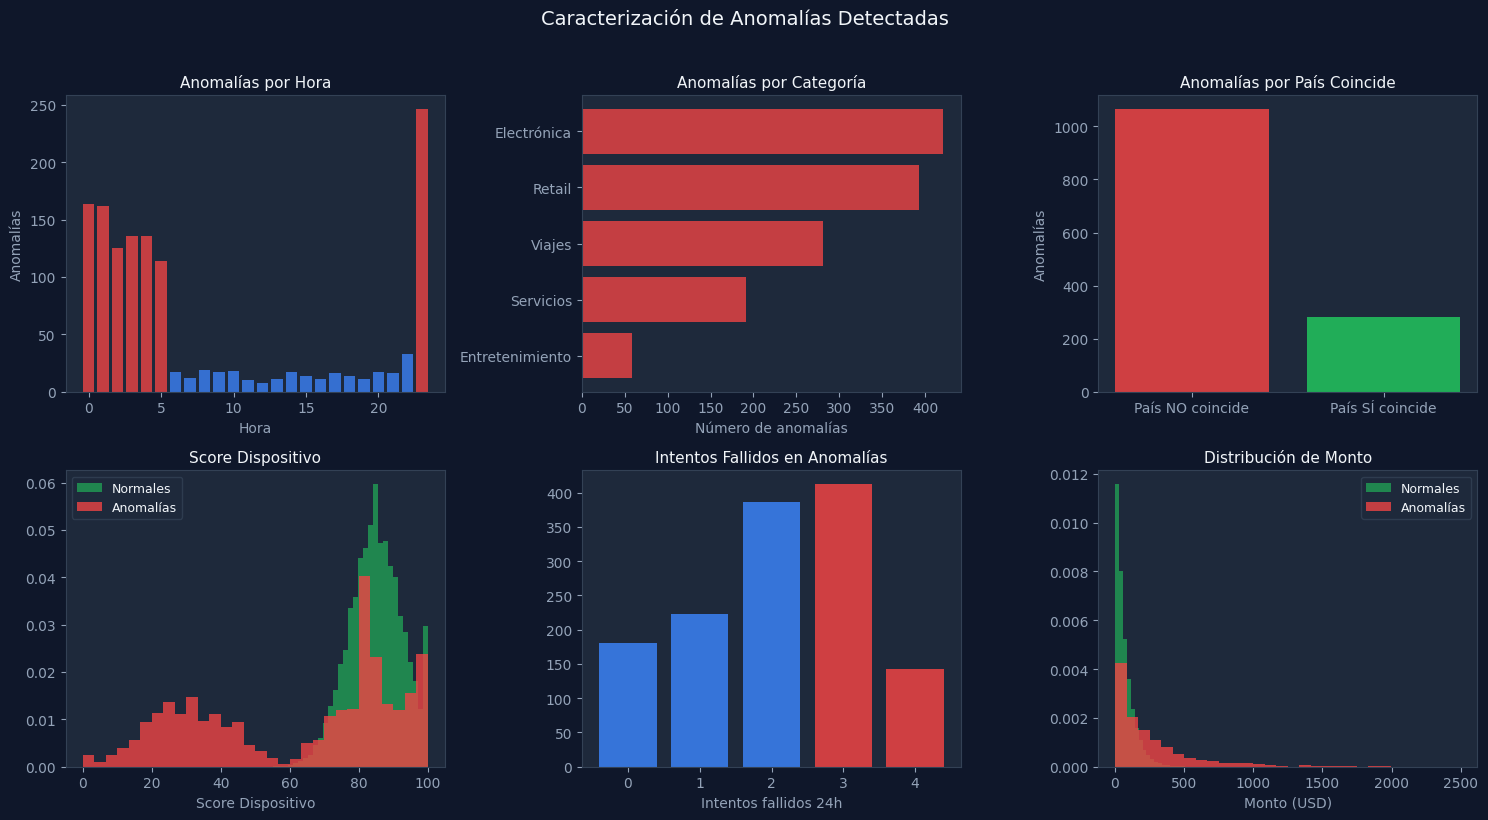

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='#0F172A')
axes = axes.flatten()

# Hora de las anomalías
for h in range(24):
    cnt_anom   = (anomalias_df['hora'] == h).sum()
    axes[0].bar(h, cnt_anom, color=ROJO if h >= 23 or h <= 5 else AZUL, alpha=0.8)
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Anomalías')
axes[0].set_title('Anomalías por Hora', color='#F1F5F9', fontsize=11)

# Categoría de las anomalías
cat_anom = anomalias_df['categoria_comercio'].value_counts()
axes[1].barh(cat_anom.index[::-1], cat_anom.values[::-1], color=ROJO, alpha=0.8)
axes[1].set_xlabel('Número de anomalías')
axes[1].set_title('Anomalías por Categoría', color='#F1F5F9', fontsize=11)

# País coincide
pais_anom = anomalias_df['pais_coincide'].value_counts()
labels_pais = ['País NO coincide', 'País SÍ coincide']
axes[2].bar(labels_pais, [pais_anom.get(0,0), pais_anom.get(1,0)], color=[ROJO, VERDE], alpha=0.85)
axes[2].set_ylabel('Anomalías')
axes[2].set_title('Anomalías por País Coincide', color='#F1F5F9', fontsize=11)

# Score dispositivo en anomalías vs normales
axes[3].hist(normales_df['score_dispositivo'],  bins=40, color=VERDE, alpha=0.6, label='Normales', density=True)
axes[3].hist(anomalias_df['score_dispositivo'], bins=30, color=ROJO,  alpha=0.8, label='Anomalías', density=True)
axes[3].set_xlabel('Score Dispositivo')
axes[3].set_title('Score Dispositivo', color='#F1F5F9', fontsize=11)
axes[3].legend(facecolor='#1E293B', edgecolor='#334155', fontsize=9)

# Intentos fallidos
intentos_anom = anomalias_df['intentos_fallidos_24h'].value_counts().sort_index()
axes[4].bar(intentos_anom.index, intentos_anom.values,
            color=[ROJO if i>=3 else AZUL for i in intentos_anom.index], alpha=0.85)
axes[4].set_xlabel('Intentos fallidos 24h')
axes[4].set_title('Intentos Fallidos en Anomalías', color='#F1F5F9', fontsize=11)

# Monto
axes[5].hist(normales_df['monto'],  bins=50, color=VERDE, alpha=0.6, label='Normales', density=True)
axes[5].hist(anomalias_df['monto'], bins=30, color=ROJO,  alpha=0.8, label='Anomalías', density=True)
axes[5].set_xlabel('Monto (USD)')
axes[5].set_title('Distribución de Monto', color='#F1F5F9', fontsize=11)
axes[5].legend(facecolor='#1E293B', edgecolor='#334155', fontsize=9)

plt.suptitle('Caracterización de Anomalías Detectadas', color='#F1F5F9', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Conclusiones operativas

El valor del modelo no supervisado no está en reemplazar a los clasificadores supervisados sino en complementarlos. Detecta patrones que el supervisado no vio, y puede usarse en producción sin esperar etiquetas. Los hallazgos de esta sección informan directamente las reglas de negocio y las features para futuras versiones del modelo supervisado.

In [13]:
print('=== RESUMEN EJECUTIVO ===')
print(f'Modelo: Isolation Forest | contamination = {contamination:.4f}')
print(f'Total transacciones:           {len(df):,}')
print(f'Anomalías detectadas:          {n_anomalias:,} ({n_anomalias/len(df)*100:.2f}%)')
print(f'Fraudes capturados (vs target):{tp_anom} de {df["target"].sum()} ({tp_anom/df["target"].sum()*100:.1f}%)')
print(f'Precision vs target:           {prec:.3f}')
print(f'Recall vs target:              {rec:.3f}')
print(f'\n🎯 Sin usar ninguna etiqueta, el modelo captura el {tp_anom/df["target"].sum()*100:.0f}%')
print(f'   de los fraudes conocidos mediante reglas de comportamiento observable.')

=== RESUMEN EJECUTIVO ===
Modelo: Isolation Forest | contamination = 0.0269
Total transacciones:           50,000
Anomalías detectadas:          1,344 (2.69%)
Fraudes capturados (vs target):718 de 750 (95.7%)
Precision vs target:           0.534
Recall vs target:              0.957

🎯 Sin usar ninguna etiqueta, el modelo captura el 96%
   de los fraudes conocidos mediante reglas de comportamiento observable.
